# CDT v2: Morris CRISPRi Cell-Level Training — Stage 1.5 (TSS + SNP Unified)

## Overview
- **Goal**: Train CDT on per-cell CRISPRi effects for mechanism understanding
- **Input**: DNA (Enformer embedding) + RNA (**per-cell** expression)
- **Output**: Per-cell log2 fold change on **2,361 genes** (2,360 + GFI1B)
- **Data Sources**:
  - **TSS perturbation**: 27 genes, 8,250 cells (positive controls)
  - **SNP perturbation**: 420 loci, 7,407 cells (enhancer/regulatory CRISPRi)
  - **Combined**: 15,657 cells (Train ~13,600 + Val ~2,037)

## Stage 1.5 Changes (vs Stage 1)
1. **GFI1B added to gene list**: 2,360 → **2,361** genes → RNA Self-Attention analysis of GFI1B network
2. **Extended training**: epochs=**1000**, patience=**50** (was 200/20)
3. **Checkpoint resume**: Saves optimizer/scheduler state for Colab session recovery

## Key Design: Unified TSS + SNP Dataset
```
TSS perturbation cell:
  DNA: Enformer(gene TSS)     [896, 3072]  (from morris_28genes_enformer.h5)
  RNA: Cell's expression       [2361]       (unique per cell, +GFI1B)
  Target: log2FC               [2361]

SNP perturbation cell:
  DNA: Enformer(SNP position)  [896, 3072]  (from morris_snp_enformer.h5)
  RNA: Cell's expression       [2361]       (unique per cell, +GFI1B)
  Target: log2FC               [2361]
```

The CDT model architecture is **identical** — only the DNA embedding center changes.
SNP perturbation = CRISPRi of enhancer/regulatory regions, which is Enformer/CDT's core use case.

## Architecture (unchanged)
```
DNA [896, 3072] -> Projector -> Self-Attn(2 layers)
                       | Cross-Attn
RNA [2361] -> RawEncoder -> Self-Attn(1 layer)
                       |
                     VCE (2 modalities)
                       |
                  Task Layer -> [2361] log2FC
```

## Train/Val Split
- **Val (TSS only)**: 5 genes (~2,037 cells) - GFI1B, CD52, TFRC, CD44, TNFSF9
- **Train**: 22 TSS genes (~6,213 cells) + ALL 420 SNP loci (7,407 cells) = ~13,620 cells

## 1. Setup

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Check GPU
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch version: 2.9.0+cu126
CUDA available: True
GPU: NVIDIA A100-SXM4-80GB
GPU Memory: 85.2 GB


In [ ]:
!pip install h5py tqdm scipy -q

import os
import h5py
import json
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
from tqdm import tqdm
from datetime import datetime
from scipy.stats import pearsonr
from dataclasses import dataclass
from typing import Optional, List, Dict

class NumpyEncoder(json.JSONEncoder):
    """JSON encoder that handles numpy types."""
    def default(self, obj):
        if isinstance(obj, np.integer):
            return int(obj)
        if isinstance(obj, np.floating):
            return float(obj)
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        if isinstance(obj, np.bool_):
            return bool(obj)
        return super().default(obj)

print("All imports successful!")

All imports successful!


## 2. Paths Configuration

In [ ]:
# Google Drive paths
DRIVE_BASE = Path("/content/drive/MyDrive/cdt_data")
OUTPUT_BASE = Path("/content/drive/MyDrive/cdt_outputs/morris_crispri_stage1_5")
OUTPUT_BASE.mkdir(parents=True, exist_ok=True)

# TSS cell-level effects (generated by compute_celllevel_effects_stage1_5.py)
TSS_CELLLEVEL_PATH = DRIVE_BASE / "morris_celllevel_effects_2361.h5"

# SNP cell-level effects (generated by compute_celllevel_effects_stage1_5.py)
SNP_CELLLEVEL_PATH = DRIVE_BASE / "morris_snp_celllevel_effects_2361.h5"

# Enformer embeddings (unchanged from Stage 1)
TSS_ENFORMER_PATH = DRIVE_BASE / "morris_28genes_enformer.h5"
SNP_ENFORMER_PATH = DRIVE_BASE / "morris_snp_enformer.h5"

# Check files
print("Checking files...")
for name, path in [
    ("TSS cell-level effects (2361)", TSS_CELLLEVEL_PATH),
    ("SNP cell-level effects (2361)", SNP_CELLLEVEL_PATH),
    ("TSS Enformer embeddings", TSS_ENFORMER_PATH),
    ("SNP Enformer embeddings", SNP_ENFORMER_PATH),
]:
    if path.exists():
        size_mb = path.stat().st_size / 1e6
        print(f"  [OK] {name}: {path.name} ({size_mb:.1f} MB)")
    else:
        print(f"  [NOT FOUND] {name}: {path}")

# Flag for whether SNP data is available
HAS_SNP_DATA = SNP_CELLLEVEL_PATH.exists() and SNP_ENFORMER_PATH.exists()
print(f"\nSNP data available: {HAS_SNP_DATA}")
if not HAS_SNP_DATA:
    print("  Will run TSS-only mode (fallback)")
    print("  To enable SNP: run Phase A+B (Colab) and Phase C (local) first")

Checking files...
  [OK] TSS cell-level effects (2361): morris_celllevel_effects_2361.h5 (42.9 MB)
  [OK] SNP cell-level effects (2361): morris_snp_celllevel_effects_2361.h5 (35.3 MB)
  [OK] TSS Enformer embeddings: morris_28genes_enformer.h5 (290.0 MB)
  [OK] SNP Enformer embeddings: morris_snp_enformer.h5 (5104.4 MB)

SNP data available: True


## 3. Load Data

In [ ]:
# Load TSS cell-level effects
print("=" * 60)
print("Loading TSS cell-level effects...")
with h5py.File(TSS_CELLLEVEL_PATH, 'r') as f:
    tss_log2fc = f['log2fc'][:]           # [n_tss_cells, 2360]
    tss_cell_expr = f['cell_expr'][:]     # [n_tss_cells, 2360]
    tss_target_gene_idx = f['target_gene_idx'][:]  # [n_tss_cells]

    target_gene_names = [g.decode() if isinstance(g, bytes) else g
                         for g in f['target_gene_names'][:]]
    n_cells_per_gene = f['n_cells_per_gene'][:]
    cdt_genes = [g.decode() if isinstance(g, bytes) else g
                 for g in f['gene_names_cdt'][:]]
    ntc_mean_expr = f['ntc_mean_expr'][:]  # [2360] NTC baseline

    train_genes = [g.decode() if isinstance(g, bytes) else g
                   for g in f['train_genes'][:]]
    val_genes = [g.decode() if isinstance(g, bytes) else g
                 for g in f['val_genes'][:]]

    n_tss_cells = f.attrs['n_cells']
    n_ntc = f.attrs['n_ntc_cells']
    umi_threshold = f.attrs['umi_threshold']
    method = f.attrs['method']

print(f"  TSS cells: {n_tss_cells}")
print(f"  CDT genes: {len(cdt_genes)}")
print(f"  Target genes: {len(target_gene_names)}")
print(f"  Train genes ({len(train_genes)}): {train_genes}")
print(f"  Val genes ({len(val_genes)}): {val_genes}")

# Load SNP cell-level effects (if available)
if HAS_SNP_DATA:
    print("\nLoading SNP cell-level effects...")
    with h5py.File(SNP_CELLLEVEL_PATH, 'r') as f:
        snp_log2fc = f['log2fc'][:]               # [n_snp_cells, 2360]
        snp_cell_expr = f['cell_expr'][:]          # [n_snp_cells, 2360]
        snp_perturbation_idx = f['perturbation_idx'][:]  # [n_snp_cells]

        snp_loci_names = [g.decode() if isinstance(g, bytes) else g
                          for g in f['snp_loci_names'][:]]
        snp_ids = f['snp_ids'][:]
        n_cells_per_locus = f['n_cells_per_locus'][:]

        n_snp_cells = f.attrs['n_cells']
        n_snp_loci = f.attrs['n_loci']

    print(f"  SNP cells: {n_snp_cells}")
    print(f"  SNP loci: {n_snp_loci}")
    print(f"  Cells per locus: mean={n_cells_per_locus.mean():.1f}, median={np.median(n_cells_per_locus):.0f}")
else:
    snp_log2fc = None
    snp_cell_expr = None
    snp_perturbation_idx = None
    n_snp_cells = 0
    n_snp_loci = 0

print(f"\nTotal cells: TSS={n_tss_cells} + SNP={n_snp_cells} = {n_tss_cells + n_snp_cells}")

Loading TSS cell-level effects...
  TSS cells: 8250
  CDT genes: 2361
  Target genes: 27
  Train genes (22): ['B2M', 'CD19', 'CD40', 'CD58', 'CD69', 'CD81', 'CD82', 'CD83', 'ENTPD1', 'EPCAM', 'FCGR2A', 'ICAM1', 'IL21R', 'ITGAE', 'ITGB1', 'KLRD1', 'KLRG1', 'LGALS3', 'MSR1', 'NECTIN2', 'SLC3A2', 'TNFSF13B']
  Val genes (5): ['CD44', 'CD52', 'GFI1B', 'TFRC', 'TNFSF9']

Loading SNP cell-level effects...
  SNP cells: 7407
  SNP loci: 420
  Cells per locus: mean=17.6, median=8

Total cells: TSS=8250 + SNP=7407 = 15657


In [ ]:
# Load Enformer embeddings
print("Loading TSS Enformer embeddings...")
with h5py.File(TSS_ENFORMER_PATH, 'r') as f:
    tss_enformer_emb = f['embeddings'][:]  # [28, 896, 3072]
    tss_enformer_genes = [g.decode() if isinstance(g, bytes) else g
                          for g in f['gene_names'][:]]

print(f"  TSS Shape: {tss_enformer_emb.shape}")
print(f"  TSS Genes: {len(tss_enformer_genes)}")

# Build mapping: TSS target gene index -> Enformer index
tss_target_to_enformer = {}
for i, gene in enumerate(target_gene_names):
    if gene in tss_enformer_genes:
        tss_target_to_enformer[i] = tss_enformer_genes.index(gene)
    else:
        print(f"  Warning: {gene} not in TSS Enformer")

print(f"  TSS Matched: {len(tss_target_to_enformer)}/{len(target_gene_names)}")

# Load SNP Enformer embeddings (if available)
if HAS_SNP_DATA:
    print("\nLoading SNP Enformer embeddings...")
    with h5py.File(SNP_ENFORMER_PATH, 'r') as f:
        snp_enformer_emb = f['embeddings'][:]  # [n_loci, 896, 3072]
        snp_enformer_ids = f['snp_ids'][:]

    print(f"  SNP Shape: {snp_enformer_emb.shape}")
    print(f"  SNP Loci: {len(snp_enformer_ids)}")

    # Build mapping: snp_id -> Enformer index
    snp_id_to_enformer = {int(sid): i for i, sid in enumerate(snp_enformer_ids)}

    # Build mapping: perturbation_idx (in SNP effects file) -> Enformer index
    snp_pert_to_enformer = {}
    for pert_idx, locus_name in enumerate(snp_loci_names):
        # snp_loci_names format: "SNP-{id}"
        sid = int(locus_name.split('-')[1])
        if sid in snp_id_to_enformer:
            snp_pert_to_enformer[pert_idx] = snp_id_to_enformer[sid]

    print(f"  SNP Matched: {len(snp_pert_to_enformer)}/{len(snp_loci_names)}")
else:
    snp_enformer_emb = None
    snp_pert_to_enformer = {}

# Also keep backward-compatible names for attention analysis section
enformer_emb = tss_enformer_emb
enformer_genes = tss_enformer_genes
target_to_enformer = tss_target_to_enformer

Loading TSS Enformer embeddings...
  TSS Shape: (28, 896, 3072)
  TSS Genes: 28
  TSS Matched: 27/27

Loading SNP Enformer embeddings...
  SNP Shape: (493, 896, 3072)
  SNP Loci: 493
  SNP Matched: 420/420


In [ ]:
# Data summary
print("=" * 60)
print("Data Summary")
print("=" * 60)

train_set = set(train_genes)
val_set = set(val_genes)

print(f"\n--- TSS Perturbations ---")
print(f"Per-gene cell counts:")
for i, gene in enumerate(target_gene_names):
    split = "VAL" if gene in val_genes else "train"
    print(f"  {gene:12s}: {n_cells_per_gene[i]:5d} cells [{split}]")

tss_train_mask = np.array([target_gene_names[idx] in train_set for idx in tss_target_gene_idx])
tss_val_mask = ~tss_train_mask
print(f"\nTSS Train cells: {tss_train_mask.sum()}")
print(f"TSS Val cells:   {tss_val_mask.sum()}")

if HAS_SNP_DATA:
    print(f"\n--- SNP Perturbations ---")
    print(f"SNP loci: {n_snp_loci}")
    print(f"SNP cells: {n_snp_cells}")
    print(f"All SNP cells go to TRAIN (no SNP validation genes)")
    print(f"\n--- Combined ---")
    total_train = int(tss_train_mask.sum()) + n_snp_cells
    total_val = int(tss_val_mask.sum())
    print(f"Total Train: {total_train} (TSS: {int(tss_train_mask.sum())} + SNP: {n_snp_cells})")
    print(f"Total Val:   {total_val} (TSS only: {val_genes})")
    print(f"Scale-up: {total_train / max(1, int(tss_train_mask.sum())):.1f}x training data")

# Log2FC statistics
print(f"\nTSS log2FC stats:")
print(f"  Mean: {tss_log2fc.mean():.4f}, Std: {tss_log2fc.std():.4f}")

if HAS_SNP_DATA:
    print(f"\nSNP log2FC stats:")
    print(f"  Mean: {snp_log2fc.mean():.4f}, Std: {snp_log2fc.std():.4f}")
    print(f"\n  Note: SNP effects should be smaller than TSS effects")
    print(f"  (enhancer CRISPRi < promoter knockdown)")

Data Summary

--- TSS Perturbations ---
Per-gene cell counts:
  B2M         :   220 cells [train]
  CD19        :    65 cells [train]
  CD40        :    12 cells [train]
  CD44        :   233 cells [VAL]
  CD52        :   131 cells [VAL]
  CD58        :   946 cells [train]
  CD69        :   306 cells [train]
  CD81        :   298 cells [train]
  CD82        :   252 cells [train]
  CD83        :    71 cells [train]
  ENTPD1      :   504 cells [train]
  EPCAM       :    64 cells [train]
  FCGR2A      :   300 cells [train]
  GFI1B       :   477 cells [VAL]
  ICAM1       :   117 cells [train]
  IL21R       :   210 cells [train]
  ITGAE       :   380 cells [train]
  ITGB1       :   299 cells [train]
  KLRD1       :   518 cells [train]
  KLRG1       :   224 cells [train]
  LGALS3      :   158 cells [train]
  MSR1        :    64 cells [train]
  NECTIN2     :    77 cells [train]
  SLC3A2      :   428 cells [train]
  TFRC        :   847 cells [VAL]
  TNFSF13B    :   700 cells [train]
  TNFSF9  

## 4. Model Definition

In [ ]:
@dataclass
class CDTCRISPRiConfig:
    """Config for CRISPRi effect prediction"""
    dna_dim: int = 3072
    dna_seq_len: int = 896
    n_genes: int = 2361  # Stage 1.5: 2360 + GFI1B
    hidden_dim: int = 512
    nhead: int = 8
    dropout: float = 0.3
    dna_self_attn_layers: int = 2
    rna_self_attn_layers: int = 1


class RawExpressionEncoder(nn.Module):
    """Raw expression -> hidden_dim embeddings"""
    def __init__(self, n_genes: int, hidden_dim: int, dropout: float = 0.1):
        super().__init__()
        self.n_genes = n_genes
        self.hidden_dim = hidden_dim

        self.gene_embedding = nn.Embedding(n_genes, hidden_dim)
        self.expr_projector = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout)
        )
        self.combine = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.Dropout(dropout)
        )

    def forward(self, expression: torch.Tensor) -> torch.Tensor:
        batch_size = expression.size(0)
        device = expression.device

        gene_ids = torch.arange(self.n_genes, device=device)
        gene_emb = self.gene_embedding(gene_ids)
        gene_emb = gene_emb.unsqueeze(0).expand(batch_size, -1, -1)

        expr_emb = self.expr_projector(expression.unsqueeze(-1))

        combined = torch.cat([gene_emb, expr_emb], dim=-1)
        return self.combine(combined)


class SequenceProjector(nn.Module):
    def __init__(self, input_dim: int, output_dim: int, dropout: float = 0.1):
        super().__init__()
        self.linear = nn.Linear(input_dim, output_dim)
        self.norm = nn.LayerNorm(output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.dropout(self.norm(self.linear(x)))


class FlashSelfAttentionBlock(nn.Module):
    def __init__(self, d_model: int, nhead: int = 8, dropout: float = 0.1):
        super().__init__()
        self.d_model = d_model
        self.nhead = nhead
        self.head_dim = d_model // nhead
        self.dropout_p = dropout

        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)

        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_model * 4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 4, d_model),
            nn.Dropout(dropout)
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor, return_attn=False):
        batch_size, seq_len, _ = x.shape

        Q = self.q_proj(x).view(batch_size, seq_len, self.nhead, self.head_dim).transpose(1, 2)
        K = self.k_proj(x).view(batch_size, seq_len, self.nhead, self.head_dim).transpose(1, 2)
        V = self.v_proj(x).view(batch_size, seq_len, self.nhead, self.head_dim).transpose(1, 2)

        if return_attn:
            # Manual attention for extracting weights
            scale = self.head_dim ** -0.5
            attn_weights = torch.matmul(Q, K.transpose(-2, -1)) * scale
            attn_weights = F.softmax(attn_weights, dim=-1)
            attn_out = torch.matmul(attn_weights, V)
        else:
            attn_out = F.scaled_dot_product_attention(
                Q, K, V,
                dropout_p=self.dropout_p if self.training else 0.0
            )
            attn_weights = None

        attn_out = attn_out.transpose(1, 2).contiguous().view(batch_size, seq_len, self.d_model)
        attn_out = self.out_proj(attn_out)

        x = self.norm1(x + self.dropout(attn_out))
        x = self.norm2(x + self.ffn(x))

        if return_attn:
            return x, attn_weights
        return x


class FlashCrossAttentionBlock(nn.Module):
    def __init__(self, d_model: int, nhead: int = 8, dropout: float = 0.1):
        super().__init__()
        self.d_model = d_model
        self.nhead = nhead
        self.head_dim = d_model // nhead
        self.dropout_p = dropout

        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)

        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_model * 4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 4, d_model),
            nn.Dropout(dropout)
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, query: torch.Tensor, key_value: torch.Tensor, return_attn=False):
        batch_size, query_len, _ = query.shape
        key_len = key_value.shape[1]

        Q = self.q_proj(query).view(batch_size, query_len, self.nhead, self.head_dim).transpose(1, 2)
        K = self.k_proj(key_value).view(batch_size, key_len, self.nhead, self.head_dim).transpose(1, 2)
        V = self.v_proj(key_value).view(batch_size, key_len, self.nhead, self.head_dim).transpose(1, 2)

        if return_attn:
            scale = self.head_dim ** -0.5
            attn_weights = torch.matmul(Q, K.transpose(-2, -1)) * scale
            attn_weights = F.softmax(attn_weights, dim=-1)
            attn_out = torch.matmul(attn_weights, V)
        else:
            attn_out = F.scaled_dot_product_attention(
                Q, K, V,
                dropout_p=self.dropout_p if self.training else 0.0
            )
            attn_weights = None

        attn_out = attn_out.transpose(1, 2).contiguous().view(batch_size, query_len, self.d_model)
        attn_out = self.out_proj(attn_out)

        x = self.norm1(query + self.dropout(attn_out))
        x = self.norm2(x + self.ffn(x))

        if return_attn:
            return x, attn_weights
        return x


print("Encoder and attention blocks defined!")

Encoder and attention blocks defined!


In [ ]:
class VirtualCellEmbedderDNARNA(nn.Module):
    """VCE: DNA + RNA only (2 modalities)"""

    def __init__(self, d_model: int, dropout: float = 0.1):
        super().__init__()
        self.d_model = d_model
        self.nhead = 4
        self.head_dim = d_model // self.nhead

        self.dna_query = nn.Parameter(torch.randn(1, 1, d_model))
        self.rna_query = nn.Parameter(torch.randn(1, 1, d_model))

        self.dna_q_proj = nn.Linear(d_model, d_model)
        self.dna_k_proj = nn.Linear(d_model, d_model)
        self.dna_v_proj = nn.Linear(d_model, d_model)
        self.dna_out_proj = nn.Linear(d_model, d_model)

        self.rna_q_proj = nn.Linear(d_model, d_model)
        self.rna_k_proj = nn.Linear(d_model, d_model)
        self.rna_v_proj = nn.Linear(d_model, d_model)
        self.rna_out_proj = nn.Linear(d_model, d_model)

        self.fusion = nn.Sequential(
            nn.Linear(d_model * 2, d_model * 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 2, d_model),
            nn.LayerNorm(d_model)
        )

    def _attention_pool(self, query, key_value, q_proj, k_proj, v_proj, out_proj):
        batch_size = key_value.size(0)
        seq_len = key_value.size(1)
        query = query.expand(batch_size, -1, -1)

        Q = q_proj(query).view(batch_size, 1, self.nhead, self.head_dim).transpose(1, 2)
        K = k_proj(key_value).view(batch_size, seq_len, self.nhead, self.head_dim).transpose(1, 2)
        V = v_proj(key_value).view(batch_size, seq_len, self.nhead, self.head_dim).transpose(1, 2)

        attn_out = F.scaled_dot_product_attention(Q, K, V)
        attn_out = attn_out.transpose(1, 2).contiguous().view(batch_size, 1, self.d_model)
        return out_proj(attn_out).squeeze(1)

    def forward(self, dna_encoded, rna_encoded):
        dna_pooled = self._attention_pool(
            self.dna_query, dna_encoded,
            self.dna_q_proj, self.dna_k_proj, self.dna_v_proj, self.dna_out_proj
        )
        rna_pooled = self._attention_pool(
            self.rna_query, rna_encoded,
            self.rna_q_proj, self.rna_k_proj, self.rna_v_proj, self.rna_out_proj
        )

        concat = torch.cat([dna_pooled, rna_pooled], dim=-1)
        return self.fusion(concat)


class CDTCRISPRiModel(nn.Module):
    """
    CDT Model for CRISPRi Effect Prediction

    Input:
        - dna_emb: [batch, 896, 3072] TSS-centered Enformer
        - rna_expr: [batch, n_genes] per-cell expression

    Output:
        - effect: [batch, n_genes] log2 fold change prediction
    """

    def __init__(self, config: Optional[CDTCRISPRiConfig] = None):
        super().__init__()
        if config is None:
            config = CDTCRISPRiConfig()
        self.config = config

        # DNA
        self.dna_projector = SequenceProjector(config.dna_dim, config.hidden_dim, config.dropout)
        self.dna_self_attn_layers = nn.ModuleList([
            FlashSelfAttentionBlock(config.hidden_dim, config.nhead, config.dropout)
            for _ in range(config.dna_self_attn_layers)
        ])

        # RNA
        self.rna_encoder = RawExpressionEncoder(config.n_genes, config.hidden_dim, config.dropout)
        self.rna_self_attn_layers = nn.ModuleList([
            FlashSelfAttentionBlock(config.hidden_dim, config.nhead, config.dropout)
            for _ in range(config.rna_self_attn_layers)
        ])

        # Cross-Attention: DNA -> RNA
        self.dna_to_rna = FlashCrossAttentionBlock(config.hidden_dim, config.nhead, config.dropout)

        # VCE
        self.vce = VirtualCellEmbedderDNARNA(config.hidden_dim, config.dropout)

        # Task: Predict effect on all genes
        self.task_layer = nn.Sequential(
            nn.Linear(config.hidden_dim, config.hidden_dim),
            nn.GELU(),
            nn.Dropout(config.dropout),
            nn.Linear(config.hidden_dim, config.n_genes)
        )

    def forward(self, dna_emb, rna_expr, return_intermediates=False):
        # Encode
        dna = self.dna_projector(dna_emb)
        rna = self.rna_encoder(rna_expr)

        # Self-Attention
        for layer in self.dna_self_attn_layers:
            dna = layer(dna)
        for layer in self.rna_self_attn_layers:
            rna = layer(rna)

        # Cross-Attention
        rna = self.dna_to_rna(query=rna, key_value=dna)

        # VCE
        cell_embedding = self.vce(dna, rna)

        # Task
        effect = self.task_layer(cell_embedding)

        if return_intermediates:
            return effect, {'dna': dna, 'rna': rna, 'vce': cell_embedding}
        return effect

    def get_num_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


print("CDTCRISPRiModel defined!")

CDTCRISPRiModel defined!


## 5. Dataset

In [ ]:
class MorrisCellLevelDataset(Dataset):
    """Cell-level CRISPRi Dataset (TSS only).

    Each sample = one perturbed cell.
    - DNA: Enformer embedding for the target gene's TSS
    - RNA: Cell's actual expression (per-cell, unique!)
    - Target: Per-cell log2FC
    """

    def __init__(self, indices, log2fc, cell_expr, target_gene_idx,
                 enformer_emb, target_to_enformer):
        self.indices = indices
        self.log2fc = log2fc
        self.cell_expr = cell_expr
        self.target_gene_idx = target_gene_idx
        self.enformer_emb = enformer_emb
        self.target_to_enformer = target_to_enformer

        self.valid_indices = [
            idx for idx in indices
            if target_gene_idx[idx] in target_to_enformer
        ]

        n_filtered = len(indices) - len(self.valid_indices)
        if n_filtered > 0:
            print(f"  Filtered {n_filtered} cells (missing Enformer)")

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        cell_idx = self.valid_indices[idx]
        gene_idx = self.target_gene_idx[cell_idx]
        enf_idx = self.target_to_enformer[gene_idx]

        dna = torch.from_numpy(self.enformer_emb[enf_idx].astype(np.float32))
        rna = torch.from_numpy(self.cell_expr[cell_idx].astype(np.float32))
        effect = torch.from_numpy(self.log2fc[cell_idx].astype(np.float32))

        return dna, rna, effect


class MorrisUnifiedDataset(Dataset):
    """Unified TSS + SNP Cell-level CRISPRi Dataset.

    Combines TSS perturbation cells and SNP perturbation cells.
    Each sample = one perturbed cell.

    DNA embedding source depends on perturbation type:
    - TSS: from tss_enformer [28, 896, 3072] (indexed by target gene)
    - SNP: from snp_enformer [~508, 896, 3072] (indexed by SNP locus)
    """

    def __init__(self,
                 tss_indices, tss_log2fc, tss_cell_expr, tss_target_gene_idx,
                 tss_enformer_emb, tss_target_to_enformer,
                 snp_indices, snp_log2fc, snp_cell_expr, snp_perturbation_idx,
                 snp_enformer_emb, snp_pert_to_enformer):
        """
        Args:
            tss_indices: Cell indices for TSS perturbation data
            tss_log2fc: [n_tss_cells, n_genes] TSS log2FC
            tss_cell_expr: [n_tss_cells, n_genes] TSS cell expression
            tss_target_gene_idx: [n_tss_cells] which gene was perturbed
            tss_enformer_emb: [n_tss_genes, 896, 3072] TSS Enformer
            tss_target_to_enformer: {gene_idx: enformer_idx}
            snp_indices: Cell indices for SNP perturbation data
            snp_log2fc: [n_snp_cells, n_genes] SNP log2FC
            snp_cell_expr: [n_snp_cells, n_genes] SNP cell expression
            snp_perturbation_idx: [n_snp_cells] which locus was perturbed
            snp_enformer_emb: [n_snp_loci, 896, 3072] SNP Enformer
            snp_pert_to_enformer: {pert_idx: enformer_idx}
        """
        # TSS samples
        self.tss_valid = [
            idx for idx in tss_indices
            if tss_target_gene_idx[idx] in tss_target_to_enformer
        ]
        n_tss_filtered = len(tss_indices) - len(self.tss_valid)
        if n_tss_filtered > 0:
            print(f"  TSS: Filtered {n_tss_filtered} cells (missing Enformer)")

        # SNP samples
        self.snp_valid = [
            idx for idx in snp_indices
            if snp_perturbation_idx[idx] in snp_pert_to_enformer
        ]
        n_snp_filtered = len(snp_indices) - len(self.snp_valid)
        if n_snp_filtered > 0:
            print(f"  SNP: Filtered {n_snp_filtered} cells (missing Enformer)")

        self.n_tss = len(self.tss_valid)
        self.n_snp = len(self.snp_valid)

        # Store references
        self.tss_log2fc = tss_log2fc
        self.tss_cell_expr = tss_cell_expr
        self.tss_target_gene_idx = tss_target_gene_idx
        self.tss_enformer_emb = tss_enformer_emb
        self.tss_target_to_enformer = tss_target_to_enformer

        self.snp_log2fc = snp_log2fc
        self.snp_cell_expr = snp_cell_expr
        self.snp_perturbation_idx = snp_perturbation_idx
        self.snp_enformer_emb = snp_enformer_emb
        self.snp_pert_to_enformer = snp_pert_to_enformer

        print(f"  MorrisUnifiedDataset: {self.n_tss} TSS + {self.n_snp} SNP = {len(self)} total")

    def __len__(self):
        return self.n_tss + self.n_snp

    def __getitem__(self, idx):
        if idx < self.n_tss:
            # TSS sample
            cell_idx = self.tss_valid[idx]
            gene_idx = self.tss_target_gene_idx[cell_idx]
            enf_idx = self.tss_target_to_enformer[gene_idx]

            dna = torch.from_numpy(self.tss_enformer_emb[enf_idx].astype(np.float32))
            rna = torch.from_numpy(self.tss_cell_expr[cell_idx].astype(np.float32))
            effect = torch.from_numpy(self.tss_log2fc[cell_idx].astype(np.float32))
        else:
            # SNP sample
            snp_idx = idx - self.n_tss
            cell_idx = self.snp_valid[snp_idx]
            pert_idx = self.snp_perturbation_idx[cell_idx]
            enf_idx = self.snp_pert_to_enformer[pert_idx]

            dna = torch.from_numpy(self.snp_enformer_emb[enf_idx].astype(np.float32))
            rna = torch.from_numpy(self.snp_cell_expr[cell_idx].astype(np.float32))
            effect = torch.from_numpy(self.snp_log2fc[cell_idx].astype(np.float32))

        return dna, rna, effect


# Create train/val splits
train_set = set(train_genes)
val_set = set(val_genes)

# TSS split (gene-level)
tss_train_indices = [i for i in range(len(tss_target_gene_idx))
                     if target_gene_names[tss_target_gene_idx[i]] in train_set]
tss_val_indices = [i for i in range(len(tss_target_gene_idx))
                   if target_gene_names[tss_target_gene_idx[i]] in val_set]

print(f"TSS Train cells: {len(tss_train_indices)}")
print(f"TSS Val cells: {len(tss_val_indices)}")

if HAS_SNP_DATA:
    # ALL SNP cells go to training (no SNP validation)
    snp_train_indices = list(range(n_snp_cells))
    print(f"SNP Train cells: {len(snp_train_indices)}")

    # Create Unified datasets
    train_dataset = MorrisUnifiedDataset(
        tss_train_indices, tss_log2fc, tss_cell_expr, tss_target_gene_idx,
        tss_enformer_emb, tss_target_to_enformer,
        snp_train_indices, snp_log2fc, snp_cell_expr, snp_perturbation_idx,
        snp_enformer_emb, snp_pert_to_enformer
    )
    # Val is TSS-only (gene-level held out)
    val_dataset = MorrisCellLevelDataset(
        tss_val_indices, tss_log2fc, tss_cell_expr, tss_target_gene_idx,
        tss_enformer_emb, tss_target_to_enformer
    )
else:
    # TSS-only fallback
    train_dataset = MorrisCellLevelDataset(
        tss_train_indices, tss_log2fc, tss_cell_expr, tss_target_gene_idx,
        tss_enformer_emb, tss_target_to_enformer
    )
    val_dataset = MorrisCellLevelDataset(
        tss_val_indices, tss_log2fc, tss_cell_expr, tss_target_gene_idx,
        tss_enformer_emb, tss_target_to_enformer
    )

print(f"\nTrain dataset: {len(train_dataset)} cells")
print(f"Val dataset: {len(val_dataset)} cells")

# Backward compatibility
target_gene_idx = tss_target_gene_idx
log2fc_all = tss_log2fc
cell_expr_all = tss_cell_expr
val_indices = tss_val_indices

TSS Train cells: 6213
TSS Val cells: 2037
SNP Train cells: 7407
  MorrisUnifiedDataset: 6213 TSS + 7407 SNP = 13620 total

Train dataset: 13620 cells
Val dataset: 2037 cells


In [ ]:
# DataLoaders
BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=2, pin_memory=True
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=2, pin_memory=True
)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")

# Test one batch
dna_batch, rna_batch, effect_batch = next(iter(train_loader))
print(f"\nBatch shapes:")
print(f"  DNA: {dna_batch.shape}")
print(f"  RNA: {rna_batch.shape}")
print(f"  Effect: {effect_batch.shape}")
print(f"  RNA non-zero per cell: {(rna_batch > 0).sum(dim=1).float().mean():.0f}")

Train batches: 213
Val batches: 32

Batch shapes:
  DNA: torch.Size([64, 896, 3072])
  RNA: torch.Size([64, 2361])
  Effect: torch.Size([64, 2361])
  RNA non-zero per cell: 587


## 6. Training

In [ ]:
# Config
config = {
    'hidden_dim': 512,
    'nhead': 8,
    'dropout': 0.3,
    'batch_size': BATCH_SIZE,
    'learning_rate': 1e-4,
    'weight_decay': 1e-5,
    'epochs': 1000,       # Stage 1.5: extended from 200
    'patience': 50,      # Stage 1.5: extended from 20
    'n_genes': len(cdt_genes),
    'n_train_cells': len(train_dataset),
    'n_val_cells': len(val_dataset),
    'n_train_genes': len(train_genes),
    'n_val_genes': len(val_genes),
    'val_genes': val_genes,
    'rna_input': 'per-cell log1p(CPM)',
    'target': 'per-cell log2((cell_CPM+1)/(NTC_mean_CPM+1))',
    'has_snp_data': HAS_SNP_DATA,
    'n_snp_loci': int(n_snp_loci),
    'n_snp_cells': int(n_snp_cells),
    'dataset_type': 'unified_tss_snp' if HAS_SNP_DATA else 'tss_only',
}

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

# Model
model_config = CDTCRISPRiConfig(
    n_genes=config['n_genes'],
    hidden_dim=config['hidden_dim'],
    nhead=config['nhead'],
    dropout=config['dropout']
)
model = CDTCRISPRiModel(model_config).to(device)

print(f"\nModel parameters: {model.get_num_params():,}")
print(f"Dataset: {config['dataset_type']}")
print(f"Train: {config['n_train_cells']} cells | Val: {config['n_val_cells']} cells")
print(f"Epochs: {config['epochs']} | Patience: {config['patience']}")
print(f"Gene count: {config['n_genes']} (Stage 1.5: 2360 + GFI1B)")

Device: cuda

Model parameters: 21,072,185
Dataset: unified_tss_snp
Train: 13620 cells | Val: 2037 cells
Epochs: 1000 | Patience: 50
Gene count: 2361 (Stage 1.5: 2360 + GFI1B)


In [ ]:
# Training functions
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=config['learning_rate'],
    weight_decay=config['weight_decay']
)

criterion = nn.MSELoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=10
)


def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    all_preds = []
    all_targets = []

    for dna, rna, effect in loader:
        dna = dna.to(device)
        rna = rna.to(device)
        effect = effect.to(device)

        optimizer.zero_grad()
        pred = model(dna, rna)
        loss = criterion(pred, effect)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * dna.size(0)
        all_preds.append(pred.detach().cpu().numpy())
        all_targets.append(effect.cpu().numpy())

    all_preds = np.concatenate(all_preds).flatten()
    all_targets = np.concatenate(all_targets).flatten()
    r, _ = pearsonr(all_preds, all_targets)

    return total_loss / len(loader.dataset), r


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for dna, rna, effect in loader:
            dna = dna.to(device)
            rna = rna.to(device)
            effect = effect.to(device)

            pred = model(dna, rna)
            loss = criterion(pred, effect)

            total_loss += loss.item() * dna.size(0)
            all_preds.append(pred.cpu().numpy())
            all_targets.append(effect.cpu().numpy())

    all_preds = np.concatenate(all_preds).flatten()
    all_targets = np.concatenate(all_targets).flatten()
    r, _ = pearsonr(all_preds, all_targets)

    return total_loss / len(loader.dataset), r


print("Training functions defined!")

Training functions defined!


In [15]:
start_epoch = 0

if CHECKPOINT_PATH.exists():
    print("Resuming from checkpoint...")
    ckpt = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    optimizer.load_state_dict(ckpt['optimizer_state_dict'])
    scheduler.load_state_dict(ckpt['scheduler_state_dict'])
    best_loss = ckpt['best_loss']
    best_val_r = ckpt['best_val_r']
    patience_counter = ckpt['patience_counter']
    history = ckpt['history']
    start_epoch = ckpt['epoch'] + 1
    print(f"  Resumed from epoch {start_epoch}, best_val_r={best_val_r:.4f}")
else:
    best_loss = float('inf')
    best_val_r = -1
    patience_counter = 0
    history = {'train_loss': [], 'train_r': [], 'val_loss': [], 'val_r': []}

# --- Training Loop ---
print(f"Starting training from epoch {start_epoch} to {config['epochs']}...")
print(f"  Train: {len(train_dataset)} cells ({len(train_genes)} genes)")
print(f"  Val: {len(val_dataset)} cells ({len(val_genes)} genes: {val_genes})")
print("=" * 70)

for epoch in range(start_epoch, config['epochs']):
    train_loss, train_r = train_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_r = evaluate(model, val_loader, criterion, device)

    history['train_loss'].append(train_loss)
    history['train_r'].append(train_r)
    history['val_loss'].append(val_loss)
    history['val_r'].append(val_r)

    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']

    if (epoch + 1) % 5 == 0 or val_loss < best_loss:
        print(f"Epoch {epoch+1:3d}/{config['epochs']}: "
              f"Train Loss={train_loss:.6f} r={train_r:.4f} | "
              f"Val Loss={val_loss:.6f} r={val_r:.4f} (lr={current_lr:.1e})")

    if val_loss < best_loss:
        best_loss = val_loss
        best_val_r = val_r
        patience_counter = 0
        torch.save(model.state_dict(), OUTPUT_BASE / "cdt_morris_celllevel_best.pt")
        print(f"  -> Best model saved! (val_r={val_r:.4f})")
    else:
        patience_counter += 1

    # --- Checkpoint Save (every epoch) ---
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'best_loss': best_loss,
        'best_val_r': best_val_r,
        'patience_counter': patience_counter,
        'history': history,
    }, CHECKPOINT_PATH)

    if patience_counter >= config['patience']:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break

print("=" * 70)
print(f"Training complete!")
print(f"  Best val loss: {best_loss:.6f}")
print(f"  Best val r: {best_val_r:.4f}")
print(f"  Epochs trained: {len(history['train_loss'])}")

Resuming from checkpoint...
  Resumed from epoch 421, best_val_r=0.5728
Starting training from epoch 421 to 1000...
  Train: 13620 cells (22 genes)
  Val: 2037 cells (5 genes: ['CD44', 'CD52', 'GFI1B', 'TFRC', 'TNFSF9'])
Epoch 425/1000: Train Loss=0.072236 r=0.5839 | Val Loss=0.067181 r=0.5730 (lr=1.0e-04)
  -> Best model saved! (val_r=0.5730)
Epoch 426/1000: Train Loss=0.072203 r=0.5841 | Val Loss=0.067178 r=0.5732 (lr=1.0e-04)
  -> Best model saved! (val_r=0.5732)
Epoch 429/1000: Train Loss=0.072046 r=0.5854 | Val Loss=0.067117 r=0.5737 (lr=1.0e-04)
  -> Best model saved! (val_r=0.5737)
Epoch 430/1000: Train Loss=0.072019 r=0.5856 | Val Loss=0.067135 r=0.5735 (lr=1.0e-04)
Epoch 431/1000: Train Loss=0.072021 r=0.5856 | Val Loss=0.067049 r=0.5744 (lr=1.0e-04)
  -> Best model saved! (val_r=0.5744)
Epoch 433/1000: Train Loss=0.071976 r=0.5859 | Val Loss=0.067048 r=0.5745 (lr=1.0e-04)
  -> Best model saved! (val_r=0.5745)
Epoch 435/1000: Train Loss=0.071912 r=0.5864 | Val Loss=0.067167 r=

## 7. Results

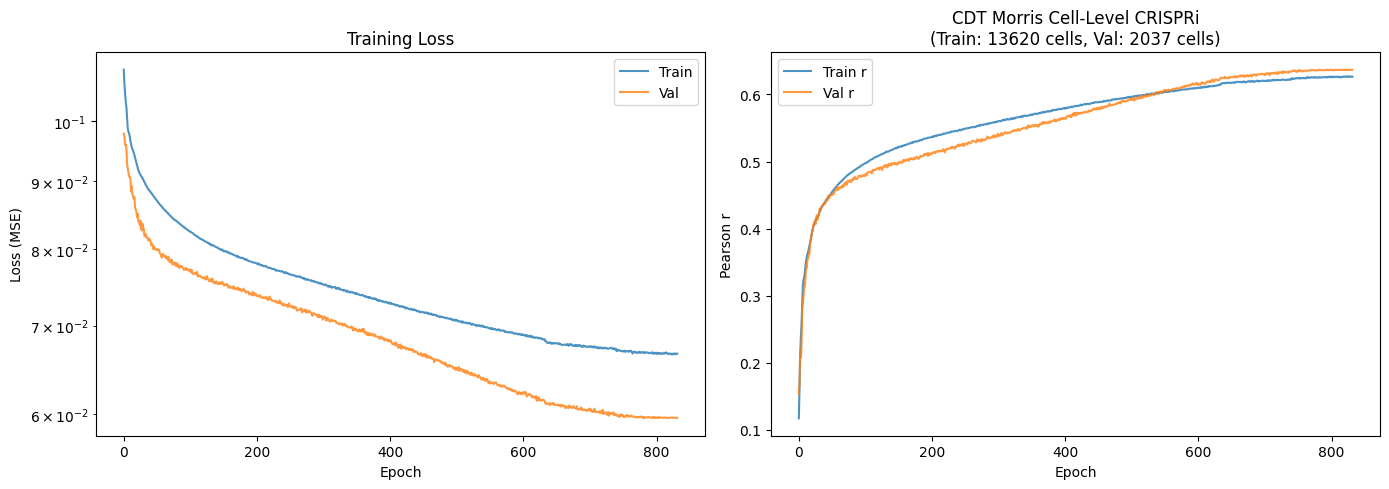

In [16]:
import matplotlib.pyplot as plt

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train_loss'], label='Train', alpha=0.8)
axes[0].plot(history['val_loss'], label='Val', alpha=0.8)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].legend()
axes[0].set_title('Training Loss')
axes[0].set_yscale('log')

axes[1].plot(history['train_r'], label='Train r', alpha=0.8)
axes[1].plot(history['val_r'], label='Val r', alpha=0.8)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Pearson r')
axes[1].legend()
axes[1].set_title(f'CDT Morris Cell-Level CRISPRi\n(Train: {len(train_dataset)} cells, Val: {len(val_dataset)} cells)')

plt.tight_layout()
plt.savefig(OUTPUT_BASE / f"training_history_{timestamp}.png", dpi=150)
plt.show()

In [17]:
# Per-gene validation analysis
print("Per-gene validation analysis:")
print("=" * 60)

model.load_state_dict(torch.load(OUTPUT_BASE / "cdt_morris_celllevel_best.pt", weights_only=True))
model.eval()

# Collect predictions per val gene
val_gene_results = {gene: {'preds': [], 'targets': []} for gene in val_genes}

with torch.no_grad():
    for dna, rna, effect in val_loader:
        dna = dna.to(device)
        rna = rna.to(device)
        pred = model(dna, rna).cpu().numpy()
        target = effect.numpy()

        # We need to figure out which gene each cell belongs to
        # Use the val_indices mapping
        # This is batch-level, so we track via dataset iteration

# Alternative: iterate over val cells manually
for gene in val_genes:
    gene_cell_indices = [
        i for i in val_indices
        if target_gene_names[target_gene_idx[i]] == gene
        and target_gene_idx[i] in target_to_enformer
    ]

    if len(gene_cell_indices) == 0:
        print(f"  {gene}: no valid cells")
        continue

    preds = []
    targets = []

    with torch.no_grad():
        for ci in gene_cell_indices:
            gi = target_gene_idx[ci]
            ei = target_to_enformer[gi]

            dna = torch.from_numpy(enformer_emb[ei].astype(np.float32)).unsqueeze(0).to(device)
            rna = torch.from_numpy(cell_expr_all[ci].astype(np.float32)).unsqueeze(0).to(device)

            pred = model(dna, rna).cpu().numpy().flatten()
            target = log2fc_all[ci]

            preds.append(pred)
            targets.append(target)

    preds = np.array(preds)
    targets = np.array(targets)

    # Overall correlation
    r_all, _ = pearsonr(preds.flatten(), targets.flatten())

    # Mean-aggregated correlation (like perturbation-level)
    mean_pred = preds.mean(axis=0)
    mean_target = targets.mean(axis=0)
    r_mean, _ = pearsonr(mean_pred, mean_target)

    # Find self-knockdown gene index in CDT genes
    if gene in cdt_genes:
        self_idx = cdt_genes.index(gene)
        self_pred = preds[:, self_idx].mean()
        self_target = targets[:, self_idx].mean()
        self_str = f"self: pred={self_pred:.3f} actual={self_target:.3f}"
    else:
        self_str = "self: gene not in CDT"

    print(f"  {gene:10s}: {len(gene_cell_indices):4d} cells | "
          f"r(all)={r_all:.3f} r(mean)={r_mean:.3f} | {self_str}")

    val_gene_results[gene] = {
        'n_cells': len(gene_cell_indices),
        'r_all': float(r_all),
        'r_mean': float(r_mean),
        'mean_pred': mean_pred,
        'mean_target': mean_target,
    }

Per-gene validation analysis:
  CD44      :  233 cells | r(all)=0.640 r(mean)=0.852 | self: gene not in CDT
  CD52      :  131 cells | r(all)=0.630 r(mean)=0.749 | self: pred=-0.136 actual=-0.172
  GFI1B     :  477 cells | r(all)=0.632 r(mean)=0.881 | self: pred=-0.086 actual=-0.093
  TFRC      :  847 cells | r(all)=0.640 r(mean)=0.853 | self: gene not in CDT
  TNFSF9    :  349 cells | r(all)=0.637 r(mean)=0.865 | self: gene not in CDT


In [ ]:
# Save results
results = {
    'version': 'stage1_5',
    'description': 'CDT Stage 1.5: 2360+GFI1B=2361 genes, epochs=1000, patience=50, checkpoint resume',
    'changes': 'GFI1B added to gene list (2360->2361), epochs=1000, patience=50, checkpoint resume',
    'config': {k: v for k, v in config.items() if not isinstance(v, (np.ndarray,)) and (not isinstance(v, list) or isinstance(v, list))},
    'best_val_loss': float(best_loss),
    'best_val_r': float(best_val_r),
    'final_train_r': float(history['train_r'][-1]),
    'final_val_r': float(history['val_r'][-1]),
    'epochs_trained': len(history['train_loss']),
    'n_train_cells': len(train_dataset),
    'n_val_cells': len(val_dataset),
    'has_snp_data': HAS_SNP_DATA,
    'n_snp_loci': int(n_snp_loci),
    'n_snp_cells': int(n_snp_cells),
    'per_gene_val': {
        gene: {'n_cells': int(r['n_cells']), 'r_all': float(r['r_all']), 'r_mean': float(r['r_mean'])}
        for gene, r in val_gene_results.items() if isinstance(r, dict) and 'n_cells' in r
    },
    'timestamp': timestamp,
}

with open(OUTPUT_BASE / f"results_{timestamp}.json", 'w') as f:
    json.dump(results, f, indent=2, cls=NumpyEncoder)

print(f"Results saved to {OUTPUT_BASE}")
print(json.dumps(results, indent=2, default=str))

## 8. Attention Map Analysis

### Purpose
Extract Attention Maps to understand cell-internal gene regulation.

### Key Questions
1. **GFI1B (Val gene)**: Can CDT discover GFI1B's 569+ trans-target network without training on GFI1B?
2. **RNA Self-Attention**: Which genes co-regulate (gene-gene network)?
3. **DNA-RNA Cross-Attention**: How does TSS position relate to gene expression changes?
4. **Cell-to-cell variation**: Do different cells show different regulatory patterns?

In [ ]:
def extract_attention_maps(model, dna_emb, rna_expr, device):
    """Extract attention maps from all layers.

    Args:
        dna_emb: [1, 896, 3072]
        rna_expr: [1, 2360]

    Returns:
        dict with attention weights from each layer
    """
    model.eval()

    with torch.no_grad():
        dna_emb = dna_emb.to(device)
        rna_expr = rna_expr.to(device)

        # Step through model manually
        dna = model.dna_projector(dna_emb)
        rna = model.rna_encoder(rna_expr)

        # DNA Self-Attention
        dna_attn_maps = []
        for layer in model.dna_self_attn_layers:
            dna, attn = layer(dna, return_attn=True)
            dna_attn_maps.append(attn.cpu().numpy())

        # RNA Self-Attention
        rna_attn_maps = []
        for layer in model.rna_self_attn_layers:
            rna, attn = layer(rna, return_attn=True)
            rna_attn_maps.append(attn.cpu().numpy())

        # Cross-Attention (DNA -> RNA)
        rna_cross, cross_attn = model.dna_to_rna(
            query=rna, key_value=dna, return_attn=True
        )
        cross_attn_map = cross_attn.cpu().numpy()

    return {
        'dna_self_attn': dna_attn_maps,     # List of [1, nhead, 896, 896]
        'rna_self_attn': rna_attn_maps,     # List of [1, nhead, 2360, 2360]
        'cross_attn': cross_attn_map,       # [1, nhead, 2360, 896]
    }


print("Attention extraction function defined!")

In [20]:
# Analyze GFI1B (Val gene - most important)
print("=" * 60)
print("GFI1B Attention Analysis")
print("CDT has NOT seen GFI1B during training")
print("=" * 60)

# Get GFI1B cells
gfi1b_gene_idx = target_gene_names.index('GFI1B')
gfi1b_cells = [i for i in val_indices if target_gene_idx[i] == gfi1b_gene_idx]
print(f"GFI1B cells: {len(gfi1b_cells)}")

# Extract attention for a few GFI1B cells
n_analyze = min(10, len(gfi1b_cells))
rna_self_attns = []
cross_attns = []

enf_idx = target_to_enformer[gfi1b_gene_idx]

for cell_i in range(n_analyze):
    ci = gfi1b_cells[cell_i]

    dna = torch.from_numpy(enformer_emb[enf_idx].astype(np.float32)).unsqueeze(0)
    rna = torch.from_numpy(cell_expr_all[ci].astype(np.float32)).unsqueeze(0)

    attn = extract_attention_maps(model, dna, rna, device)
    rna_self_attns.append(attn['rna_self_attn'][0])  # Last RNA self-attn layer
    cross_attns.append(attn['cross_attn'])

print(f"Extracted attention from {n_analyze} GFI1B cells")

# Average RNA self-attention across cells and heads
# Shape: [n_cells, 1, nhead, 2360, 2360] -> [2360, 2360]
avg_rna_attn = np.mean(
    [a[0].mean(axis=0) for a in rna_self_attns],  # Average over heads
    axis=0  # Average over cells
)
print(f"Average RNA self-attention shape: {avg_rna_attn.shape}")

GFI1B Attention Analysis
CDT has NOT seen GFI1B during training
GFI1B cells: 477
Extracted attention from 10 GFI1B cells
Average RNA self-attention shape: (2361, 2361)


In [21]:
# Find top-attended genes for GFI1B
if 'GFI1B' in cdt_genes:
    gfi1b_cdt_idx = cdt_genes.index('GFI1B')

    # Which genes does GFI1B attend to most? (row = query gene, col = key gene)
    gfi1b_attn_to_others = avg_rna_attn[gfi1b_cdt_idx, :]

    # Which genes attend to GFI1B most? (col = GFI1B as key)
    others_attn_to_gfi1b = avg_rna_attn[:, gfi1b_cdt_idx]

    # Top 30 genes that GFI1B attends to
    top_k = 30
    top_indices = np.argsort(gfi1b_attn_to_others)[-top_k:][::-1]

    print(f"\nTop {top_k} genes GFI1B attends to (RNA Self-Attention):")
    print("-" * 40)
    for rank, idx in enumerate(top_indices):
        gene = cdt_genes[idx]
        weight = gfi1b_attn_to_others[idx]
        marker = " <-- SELF" if gene == 'GFI1B' else ""
        print(f"  {rank+1:2d}. {gene:12s} (attn={weight:.4f}){marker}")

    # Top 30 genes that attend to GFI1B
    top_indices_rev = np.argsort(others_attn_to_gfi1b)[-top_k:][::-1]

    print(f"\nTop {top_k} genes that attend TO GFI1B:")
    print("-" * 40)
    for rank, idx in enumerate(top_indices_rev):
        gene = cdt_genes[idx]
        weight = others_attn_to_gfi1b[idx]
        marker = " <-- SELF" if gene == 'GFI1B' else ""
        print(f"  {rank+1:2d}. {gene:12s} (attn={weight:.4f}){marker}")
else:
    print("GFI1B not found in CDT gene list")


Top 30 genes GFI1B attends to (RNA Self-Attention):
----------------------------------------
   1. PRRC2C       (attn=0.1039)
   2. GNG5         (attn=0.0570)
   3. TAGLN2       (attn=0.0423)
   4. CDCA8        (attn=0.0310)
   5. SF3B6        (attn=0.0309)
   6. SFPQ         (attn=0.0217)
   7. PSMA5        (attn=0.0194)
   8. CDC42        (attn=0.0149)
   9. MAGOH        (attn=0.0147)
  10. KRTCAP2      (attn=0.0095)
  11. CCT4         (attn=0.0070)
  12. C1orf52      (attn=0.0067)
  13. NDUFS5       (attn=0.0065)
  14. KIF2C        (attn=0.0058)
  15. TMEM69       (attn=0.0058)
  16. PRDX1        (attn=0.0057)
  17. EIF2B3       (attn=0.0052)
  18. ATP5PB       (attn=0.0052)
  19. RPL5         (attn=0.0051)
  20. ENO1         (attn=0.0046)
  21. SNRPG        (attn=0.0045)
  22. SRP9         (attn=0.0039)
  23. PARK7        (attn=0.0038)
  24. ATP5IF1      (attn=0.0038)
  25. PSMB2        (attn=0.0038)
  26. MICOS10      (attn=0.0036)
  27. CEBPZ        (attn=0.0035)
  28. GNB1     

In [22]:
# Compare GFI1B attention with known trans-targets from Morris paper
# Known GFI1B trans-target examples: INSIG1, NPM1, BNIP3
known_gfi1b_targets = ['INSIG1', 'NPM1', 'BNIP3']

print("\nGFI1B known trans-targets attention:")
print("-" * 50)

for target in known_gfi1b_targets:
    if target in cdt_genes:
        idx = cdt_genes.index(target)
        attn_from_gfi1b = gfi1b_attn_to_others[idx]
        attn_to_gfi1b = others_attn_to_gfi1b[idx]

        # Rank among all genes
        rank_from = np.sum(gfi1b_attn_to_others > attn_from_gfi1b) + 1
        rank_to = np.sum(others_attn_to_gfi1b > attn_to_gfi1b) + 1

        print(f"  {target:10s}: GFI1B->target={attn_from_gfi1b:.4f} (rank {rank_from}/{len(cdt_genes)}) | "
              f"target->GFI1B={attn_to_gfi1b:.4f} (rank {rank_to}/{len(cdt_genes)})")
    else:
        print(f"  {target:10s}: Not in CDT gene list")

# Overall: is GFI1B attention to known targets above random?
known_idx = [cdt_genes.index(t) for t in known_gfi1b_targets if t in cdt_genes]
if known_idx:
    mean_known = gfi1b_attn_to_others[known_idx].mean()
    mean_all = gfi1b_attn_to_others.mean()
    print(f"\n  Mean attention to known targets: {mean_known:.6f}")
    print(f"  Mean attention to all genes:     {mean_all:.6f}")
    print(f"  Enrichment: {mean_known/mean_all:.1f}x")


GFI1B known trans-targets attention:
--------------------------------------------------
  INSIG1    : Not in CDT gene list
  NPM1      : Not in CDT gene list
  BNIP3     : Not in CDT gene list


In [23]:
# Analyze all Val genes
print("\n" + "=" * 60)
print("All Val Gene Attention Summary")
print("=" * 60)

for val_gene in val_genes:
    print(f"\n--- {val_gene} ---")

    vg_idx = target_gene_names.index(val_gene)
    vg_cells = [i for i in val_indices if target_gene_idx[i] == vg_idx]

    if len(vg_cells) == 0 or vg_idx not in target_to_enformer:
        print(f"  Skipped (no cells or no Enformer)")
        continue

    # Extract attention from a few cells
    n_cells = min(5, len(vg_cells))
    vg_rna_attns = []

    ei = target_to_enformer[vg_idx]
    for ci in vg_cells[:n_cells]:
        dna = torch.from_numpy(enformer_emb[ei].astype(np.float32)).unsqueeze(0)
        rna = torch.from_numpy(cell_expr_all[ci].astype(np.float32)).unsqueeze(0)
        attn = extract_attention_maps(model, dna, rna, device)
        vg_rna_attns.append(attn['rna_self_attn'][0])

    # Average
    vg_avg_attn = np.mean([a[0].mean(axis=0) for a in vg_rna_attns], axis=0)

    if val_gene in cdt_genes:
        vg_cdt_idx = cdt_genes.index(val_gene)
        vg_attn = vg_avg_attn[vg_cdt_idx, :]

        top_indices = np.argsort(vg_attn)[-10:][::-1]
        print(f"  Top 10 genes {val_gene} attends to:")
        for rank, idx in enumerate(top_indices):
            gene = cdt_genes[idx]
            weight = vg_attn[idx]
            marker = " <-- SELF" if gene == val_gene else ""
            print(f"    {rank+1:2d}. {gene:12s} (attn={weight:.4f}){marker}")


All Val Gene Attention Summary

--- CD44 ---

--- CD52 ---
  Top 10 genes CD52 attends to:
     1. TAGLN2       (attn=0.1179)
     2. MAGOH        (attn=0.0653)
     3. ATP1A1       (attn=0.0641)
     4. CDCA8        (attn=0.0441)
     5. CDC42        (attn=0.0386)
     6. KIF2C        (attn=0.0163)
     7. GUK1         (attn=0.0147)
     8. COX7A2L      (attn=0.0119)
     9. CAMTA1       (attn=0.0078)
    10. KIF14        (attn=0.0075)

--- GFI1B ---
  Top 10 genes GFI1B attends to:
     1. PRRC2C       (attn=0.1055)
     2. GNG5         (attn=0.0467)
     3. CDCA8        (attn=0.0388)
     4. TAGLN2       (attn=0.0385)
     5. MAGOH        (attn=0.0290)
     6. SF3B6        (attn=0.0277)
     7. SFPQ         (attn=0.0154)
     8. PSMA5        (attn=0.0127)
     9. CDC42        (attn=0.0127)
    10. C1orf52      (attn=0.0093)

--- TFRC ---

--- TNFSF9 ---


In [24]:
# Cell-to-cell variation: compare attention maps of different GFI1B cells
print("\n" + "=" * 60)
print("Cell-to-Cell Variation (GFI1B)")
print("=" * 60)

if len(gfi1b_cells) >= 2 and 'GFI1B' in cdt_genes:
    gfi1b_cdt_idx = cdt_genes.index('GFI1B')

    # Compare attention patterns across cells
    cell_attns = []
    for rsa in rna_self_attns:
        # Average across heads for this cell
        cell_attn = rsa[0].mean(axis=0)  # [2360, 2360]
        cell_attns.append(cell_attn[gfi1b_cdt_idx, :])  # GFI1B row

    cell_attns = np.array(cell_attns)  # [n_cells, 2360]

    # Correlation between cells
    print(f"\nAttention pattern correlation between GFI1B cells:")
    for i in range(min(5, len(cell_attns))):
        for j in range(i+1, min(5, len(cell_attns))):
            r, _ = pearsonr(cell_attns[i], cell_attns[j])
            print(f"  Cell {i} vs Cell {j}: r={r:.4f}")

    # Variance across cells
    attn_var = cell_attns.var(axis=0)  # Variance per gene
    top_var_idx = np.argsort(attn_var)[-10:][::-1]

    print(f"\nTop 10 genes with highest attention variance across GFI1B cells:")
    for rank, idx in enumerate(top_var_idx):
        gene = cdt_genes[idx]
        var = attn_var[idx]
        mean = cell_attns[:, idx].mean()
        print(f"  {rank+1:2d}. {gene:12s} (var={var:.6f}, mean_attn={mean:.4f})")
else:
    print("Not enough GFI1B cells for cell-to-cell comparison")


Cell-to-Cell Variation (GFI1B)

Attention pattern correlation between GFI1B cells:
  Cell 0 vs Cell 1: r=0.7777
  Cell 0 vs Cell 2: r=0.6950
  Cell 0 vs Cell 3: r=0.8388
  Cell 0 vs Cell 4: r=0.9443
  Cell 1 vs Cell 2: r=0.5042
  Cell 1 vs Cell 3: r=0.9711
  Cell 1 vs Cell 4: r=0.7526
  Cell 2 vs Cell 3: r=0.5731
  Cell 2 vs Cell 4: r=0.6508
  Cell 3 vs Cell 4: r=0.8190

Top 10 genes with highest attention variance across GFI1B cells:
   1. MAGOH        (var=0.000848, mean_attn=0.0147)
   2. GNG5         (var=0.000613, mean_attn=0.0570)
   3. SF3B6        (var=0.000590, mean_attn=0.0309)
   4. PRRC2C       (var=0.000329, mean_attn=0.1039)
   5. TAGLN2       (var=0.000309, mean_attn=0.0423)
   6. CDCA8        (var=0.000241, mean_attn=0.0310)
   7. SFPQ         (var=0.000232, mean_attn=0.0217)
   8. PSMA5        (var=0.000115, mean_attn=0.0194)
   9. CDC42        (var=0.000062, mean_attn=0.0149)
  10. EIF2B3       (var=0.000053, mean_attn=0.0052)


In [25]:
# Save attention analysis results
attention_results = {
    'timestamp': timestamp,
    'model': 'cdt_morris_celllevel_best.pt',
}

# Save GFI1B attention data
if 'GFI1B' in cdt_genes:
    np.savez(
        OUTPUT_BASE / f"gfi1b_attention_{timestamp}.npz",
        avg_rna_attn=avg_rna_attn,
        gfi1b_attn_to_others=gfi1b_attn_to_others,
        others_attn_to_gfi1b=others_attn_to_gfi1b,
        cdt_genes=np.array(cdt_genes, dtype='U'),
    )
    print(f"GFI1B attention saved")

print(f"\nAll outputs saved to: {OUTPUT_BASE}")
print(f"Files:")
for f in sorted(OUTPUT_BASE.iterdir()):
    size = f.stat().st_size / 1e6
    print(f"  {f.name} ({size:.1f} MB)")

GFI1B attention saved

All outputs saved to: /content/drive/MyDrive/cdt_outputs/morris_crispri_stage1_5
Files:
  cdt_morris_celllevel_best.pt (84.3 MB)
  checkpoint_latest.pt (253.1 MB)
  gfi1b_attention_20260206_014457.npz (22.4 MB)
  results_20260206_014457.json (0.0 MB)
  training_history_20260206_014457.png (0.1 MB)


## Summary — Stage 1.5

### Changes from Stage 1
| Parameter | Stage 1 | Stage 1.5 |
|-----------|---------|-----------|
| Gene count | 2,360 | **2,361** (+ GFI1B) |
| Epochs | 200 | **1000** |
| Patience | 20 | **50** |
| Checkpoint | None | **Resume-capable** |
| Output dir | morris_crispri_unified | **morris_crispri_stage1_5** |

### Data Scale
| Metric | TSS-only | Unified (TSS+SNP) |
|--------|----------|-------------------|
| Train Samples | ~6,213 | ~13,620 (6,213 TSS + 7,407 SNP) |
| Val Samples | ~2,037 | ~2,037 (TSS val only) |
| Perturbation Types | TSS (27 genes) | TSS (27 genes) + SNP (420 loci) |
| DNA Input | TSS-centered Enformer | TSS or SNP-centered Enformer |
| Gene dimensions | 2,361 | 2,361 |

### Key Analysis Enabled by GFI1B Addition
1. **RNA Self-Attention [2361×2361]**: GFI1B's regulatory network discoverable
2. **GFI1B trans-targets (569+)**: Can CDT discover them without training on GFI1B?
3. **Attention Map analysis**: GFI1B row/column in attention matrix now accessible

### Checkpoint Resume
- `checkpoint_latest.pt` saved every epoch with full training state
- Includes: model, optimizer, scheduler, history, patience counter
- On Colab session timeout: just re-run the notebook to resume

### Files Generated
- `cdt_morris_celllevel_best.pt` - Best model (by val_loss)
- `checkpoint_latest.pt` - Latest checkpoint for resume
- `training_history_*.png` - Learning curves
- `results_*.json` - Training metrics
- `gfi1b_attention_*.npz` - GFI1B attention maps

### Expected Results
- val_r: **0.51+** (Stage 1 equivalent, since 2361 ≈ 2360)
- No attention collapse (minimal gene list change)
- GFI1B RNA Self-Attention analysis newly possible